# CENSOR Frobenius-Norm Variations -- Standalone Kaggle Edition

**Fully self-contained: just upload this single `.ipynb` to Kaggle and attach
a CIFAR-10 (or CIFAR-100) Kaggle dataset as input -- no other file upload
needed.** All library code from `censor_frobenius_variations.py` is embedded
directly below; only the dataset loader is different (it looks for a
pre-existing CIFAR dataset under `/kaggle/input` first, so you don't need
internet access / `--download` on Kaggle).

**How to use on Kaggle:**
1. Create a new Kaggle Notebook, upload/import this `.ipynb`.
2. In the right sidebar, click **Add Input** and attach any CIFAR-10 (or
   CIFAR-100) "python" dataset -- e.g. search "CIFAR-10 python" in the Kaggle
   dataset search. Any dataset that unpacks to the standard
   `cifar-10-batches-py/{data_batch_1..5,test_batch}` pickle format works;
   the loader below also handles a flattened layout without the wrapping
   folder name.
3. Turn on a GPU accelerator (Settings -> Accelerator -> GPU T4 x2 or better)
   for faster training, though the tiny CNN used here also runs fine on CPU.
4. Run all cells top to bottom.

Paper: https://kaiyuanzhang.com/publications/NDSS25_Censor.pdf ("CENSOR:
Defense Against Gradient Inversion via Orthogonal Subspace Bayesian
Sampling", NDSS 2025). Official code:
https://github.com/KaiyuanZh/CENSOR (`defense.py`).

**Before reading any leak-rate number, please read this.** This notebook
implements a fast **proxy** for one specific, well-documented leakage channel
(final-FC-layer label inference, paper Eq. 7 / Zhao et al.'s iDLG, 2020) --
not the paper's actual image-reconstruction attacks (IG/GI/GGL/GIAS/GIFD) or
its MSE/LPIPS/PSNR/SSIM metrics. `raw_no_defense` leaking the label 100% of
the time simply reproduces the pre-CENSOR, well-known fact that an
undefended FC gradient trivially reveals its label -- exactly the problem
CENSOR exists to solve, not a new break of it. See the accompanying PDF
research report for the full explanation and the math behind all 32 defense
variants implemented below.


In [1]:
import importlib.util, subprocess, sys

def ensure(pkg, pip_name=None):
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name or pkg], check=True)

for pkg, pip_name in [("torch", "torch"), ("torchvision", "torchvision"), ("pandas", "pandas"), ("matplotlib", "matplotlib")]:
    ensure(pkg, pip_name)

import torch
print('torch:', torch.__version__, '| cuda available:', torch.cuda.is_available())

torch: 2.10.0+cu128 | cuda available: True


## Library (embedded) -- model, all 32 defense variants, both label-leak proxy attacks

In [2]:
"""Self-contained CENSOR Frobenius-variations library, embedded directly in
this notebook (no external .py file needed). Function bodies are copied
verbatim from `censor_frobenius_variations.py` -- see that file (or the
research report PDF) for the full mathematical documentation of every
variant; only `build_loaders` differs, replaced below with a Kaggle-input-
aware version.

Every projection/normalization formula here was checked line-by-line against
the OFFICIAL CENSOR repository's defense.py
(https://github.com/KaiyuanZh/CENSOR/blob/master/defense.py, fetched
directly), including its `generate_orthogonal_gradient`,
`normalize_orthogonal_gradient`, and `orthogonal_gradient` functions, plus its
other baselines (`additive_noise`, `gradient_clipping`, `gradient_compression`,
`perturb_representation` / Soteria) that several hybrid variants below build
on.
"""

from __future__ import annotations

import argparse
import csv
import math
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Callable

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms


TensorList = list[torch.Tensor]

class TinyCIFARNet(nn.Module):
    """Fast CIFAR-sized classifier with a final FC layer suitable for label inference."""

    def __init__(self, num_classes: int) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = nn.Linear(128, num_classes)  # in_features = 128

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        return self.fc(torch.flatten(x, 1))


@dataclass(frozen=True)
class VariantResult:
    name: str
    guess_norm: int
    guess_sign: int
    leaked_norm: bool
    leaked_sign: bool
    dot_ratio: float
    cosine: float
    norm_ratio: float
    selected_loss: float | None = None


def set_seed(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def gradient_dot(left: TensorList, right: TensorList) -> torch.Tensor:
    return sum((a.flatten() * b.flatten()).sum() for a, b in zip(left, right))


def gradient_norm(grads: TensorList) -> torch.Tensor:
    return torch.sqrt(sum(g.pow(2).sum() for g in grads))


def clone_grads(grads: TensorList) -> TensorList:
    return [g.detach().clone() for g in grads]


def compute_private_gradient(
    model: nn.Module,
    criterion: nn.Module,
    images: torch.Tensor,
    labels: torch.Tensor,
) -> tuple[TensorList, torch.Tensor]:
    model.zero_grad(set_to_none=True)
    logits = model(images)
    loss = criterion(logits, labels)
    loss.backward()
    grads = [p.grad.detach().clone() for p in model.parameters() if p.grad is not None]
    model.zero_grad(set_to_none=True)
    return grads, loss.detach()


def _orthogonalize_and_rescale(
    grad: torch.Tensor,
    candidate: torch.Tensor,
    eps: float = 1e-12,
    target_norm: torch.Tensor | float | None = None,
) -> torch.Tensor:
    """Shared primitive used by most variants below: remove `candidate`'s
    component along `grad` (Eq. 12), then rescale the residual to
    `target_norm` (defaults to ||grad||_F, i.e. the paper's own
    normalization step). Both tensors are treated as flattened vectors and
    the result is reshaped back to `grad`'s shape.
    """

    grad_flat = grad.flatten()
    cand_flat = candidate.flatten().to(grad_flat.dtype)
    denom = torch.clamp(torch.dot(grad_flat, grad_flat), min=eps)
    ortho_flat = cand_flat - (torch.dot(cand_flat, grad_flat) / denom) * grad_flat
    ortho_norm = torch.clamp(torch.linalg.vector_norm(ortho_flat), min=eps)
    tnorm = torch.linalg.vector_norm(grad_flat) if target_norm is None else target_norm
    return ((ortho_flat / ortho_norm) * tnorm).view_as(grad)


# ---------------------------------------------------------------------------
# Baseline defense variants (paper-faithful + repo-faithful)
# ---------------------------------------------------------------------------


def repo_layerwise_as_is(input_gradient: TensorList, eps: float = 1e-12) -> TensorList:
    """Reproduces the *exact* arithmetic in the official CENSOR repository's
    `defense.py::generate_orthogonal_gradient` + `normalize_orthogonal_gradient`
    (confirmed against https://github.com/KaiyuanZh/CENSOR/blob/master/defense.py),
    including a real bug: the projection scalar there is
    `torch.dot(random_flat, grad_flat) / torch.norm(grad_flat)` -- i.e. divided
    by ||gl||_F, not ||gl||_F^2 as Eq. 12 specifies. This makes the "orthogonal"
    candidate not exactly orthogonal to gl whenever ||gl||_F != 1:

        <g_l^o, gl> = <gr,gl> - (<gr,gl>/||gl||_F) * <gl,gl>
                    = <gr,gl> * (1 - ||gl||_F)         (generally != 0)

    Kept as a faithful baseline, not an invented strawman.
    """

    protected: TensorList = []
    for grad in input_gradient:
        random_grad = torch.randn_like(grad)
        random_grad = random_grad / torch.clamp(torch.linalg.vector_norm(random_grad), min=eps)

        grad_flat = grad.flatten()
        random_flat = random_grad.flatten()
        proj_scalar = torch.dot(random_flat, grad_flat) / torch.clamp(torch.linalg.vector_norm(grad_flat), min=eps)
        ortho_flat = random_flat - proj_scalar * grad_flat

        ortho = ortho_flat.view_as(grad)
        ortho_norm = torch.clamp(torch.linalg.vector_norm(ortho), min=eps)
        protected.append((ortho / ortho_norm) * torch.linalg.vector_norm(grad))
    return protected


def layerwise_frobenius(input_gradient: TensorList, eps: float = 1e-12) -> TensorList:
    """CENSOR's mechanism exactly as specified by Eq. 12 (dividing by
    ||gl||_F^2, the mathematically correct orthogonal-projection formula):
    per layer, project a Gaussian candidate onto the orthogonal complement of
    that layer's gradient, then rescale to the original layer's Frobenius
    norm. The paper's default configuration ("Layer-wise gradient" row of
    their Table VII).
    """

    return [_orthogonalize_and_rescale(g, torch.randn_like(g), eps) for g in input_gradient]


def global_frobenius(input_gradient: TensorList, eps: float = 1e-12) -> TensorList:
    """The paper's ablation alternative ("Entire gradient" row of Table
    VII): flatten the whole model into one vector, project/normalize once,
    then split back into per-parameter tensors. The paper reports this is
    slightly *less* effective at suppressing leakage than the layer-wise
    version (Table VII), which `run_layerwise_vs_entire_ablation` below
    checks against our own label-leak proxy.
    """

    flat_grad = torch.cat([g.flatten() for g in input_gradient])
    flat_ortho = _orthogonalize_and_rescale(flat_grad, torch.randn_like(flat_grad), eps)

    protected: TensorList = []
    offset = 0
    for grad in input_gradient:
        n = grad.numel()
        protected.append(flat_ortho.flatten()[offset : offset + n].view_as(grad).clone())
        offset += n
    return protected


def _find_final_layer_indices(protected: TensorList, num_classes: int) -> tuple[int, int | None]:
    idx_weight = None
    for i, g in enumerate(protected):
        if g.ndim == 2 and g.shape[0] == num_classes:
            idx_weight = i
    if idx_weight is None:
        raise ValueError("Could not find a final classifier weight gradient.")
    idx_bias = None
    if (
        idx_weight + 1 < len(protected)
        and protected[idx_weight + 1].ndim == 1
        and protected[idx_weight + 1].shape[0] == num_classes
    ):
        idx_bias = idx_weight + 1
    return idx_weight, idx_bias


def final_layer_only_frobenius(
    input_gradient: TensorList,
    num_classes: int,
    eps: float = 1e-12,
) -> TensorList:
    """Protect only the final classifier layer (weight + bias) with an exact
    global Frobenius projection; leave every other layer as the raw private
    gradient.

    Hypothesis: since Eq. 7's label-leak channel lives entirely in the final
    FC layer, a defense that concentrates its entire randomization budget
    there should be at least as effective *for this specific attack* as
    protecting the whole model. Note this is *not* what the paper evaluates
    (they always protect every layer) -- it isolates whether label-leak
    protection alone requires whole-model protection or not.
    """

    protected = clone_grads(input_gradient)
    idx_weight, idx_bias = _find_final_layer_indices(protected, num_classes)
    target_idxs = [idx_weight] + ([idx_bias] if idx_bias is not None else [])
    sub_protected = global_frobenius([protected[i] for i in target_idxs], eps=eps)
    for i, pg in zip(target_idxs, sub_protected):
        protected[i] = pg
    return protected


def row_wise_final_layer_frobenius(
    input_gradient: TensorList,
    num_classes: int,
    eps: float = 1e-12,
) -> TensorList:
    """Deliberate negative control: randomize each output-class row's
    *direction* in the final FC weight gradient independently, but preserve
    each row's own Frobenius norm exactly (bias left untouched on purpose).

    Since Eq. 7's row-norm proxy only reads ||row_i||_2 (and the sign-based
    method reads the bias gradient's sign pattern), keeping every row's norm
    and every bias entry's sign intact -- even while scrambling weight-row
    *directions* -- leaves both attacks' exact inputs untouched. This should
    leak at (or near) the same rate as `raw_no_defense` on both metrics.
    Included to confirm the harness measures what it claims to, and to make
    explicit which statistics (row norm, bias sign) a real defense needs to
    disturb -- not just weight-row direction. See `row_norm_equalized_frobenius`
    and `row_norm_permuted_frobenius` below for two variants that *do*
    disturb the row-norm statistic itself while keeping the same per-row
    orthogonal-projection geometry.
    """

    protected = clone_grads(input_gradient)
    for i, g in enumerate(protected):
        if g.ndim == 2 and g.shape[0] == num_classes:
            rows = [_orthogonalize_and_rescale(g[r], torch.randn_like(g[r]), eps) for r in range(g.shape[0])]
            protected[i] = torch.stack(rows, dim=0)
    return protected


def block_frobenius(input_gradient: TensorList, block_size: int, eps: float = 1e-12) -> TensorList:
    """Flatten the whole model gradient, then project independent contiguous
    blocks of `block_size` elements, instead of per-tensor (layerwise) or the
    entire vector (global). Interpolates between the paper's two ablation
    configurations (Table VII) at finer granularity.

    Caveat: since disjoint index ranges are orthogonal in the standard basis,
    the Euclidean norm of a concatenation of blocks always equals sqrt(sum of
    each block's squared norm), regardless of how each block's direction was
    randomized. If `block_size` evenly divides (and aligns with) the FC
    layer's row length (`in_features` = 128 for `TinyCIFARNet`), this
    reconstructs each row's *exact* original norm from its per-block norms --
    the same loophole `row_wise_final_layer_frobenius` exploits on purpose,
    but here by accident. Sweep `block_size` values that do not evenly divide
    128 to avoid this degenerate case (see the block-size ablation cell).
    """

    if block_size < 2:
        raise ValueError("block_size must be >= 2 (a length-1 block has no orthogonal complement).")

    flat_grad = torch.cat([g.flatten() for g in input_gradient])
    n = flat_grad.numel()
    flat_ortho = torch.empty_like(flat_grad)
    for start in range(0, n, block_size):
        end = min(start + block_size, n)
        g_block = flat_grad[start:end]
        if g_block.numel() < 2:
            flat_ortho[start:end] = 0.0
            continue
        flat_ortho[start:end] = _orthogonalize_and_rescale(g_block, torch.randn_like(g_block), eps)

    protected: TensorList = []
    offset = 0
    for grad in input_gradient:
        cnt = grad.numel()
        protected.append(flat_ortho[offset : offset + cnt].view_as(grad).clone())
        offset += cnt
    return protected


def low_rank_structured_frobenius(input_gradient: TensorList, rank: int, eps: float = 1e-12) -> TensorList:
    """Same orthogonal-projection geometry as `layerwise_frobenius`, but the
    random candidate gr is constrained to a rank-`rank` structured matrix
    (U @ V^T) instead of the paper's unconstrained iid Gaussian N(0, I).
    Matrix/conv-shaped tensors are reshaped to 2D (out_features, in_features)
    so the low-rank factorization applies; 1D tensors (biases) fall back to
    full Gaussian noise. `rank` is clamped to a valid range to avoid
    degenerate factorizations on near-square or tiny layers.

    Hypothesis: constraining the *random* candidate's rank could accidentally
    leave correlated structure behind, or could be just as effective as the
    paper's full-rank noise for exact orthogonal projection -- which would
    suggest the rank of the noise doesn't matter for this attack, only the
    orthogonality does.
    """

    protected: TensorList = []
    for grad in input_gradient:
        if grad.ndim >= 2:
            out_dim = grad.shape[0]
            in_dim = grad.numel() // out_dim
            r = max(1, min(rank, out_dim, in_dim))
            u = torch.randn(out_dim, r, device=grad.device, dtype=grad.dtype)
            v = torch.randn(in_dim, r, device=grad.device, dtype=grad.dtype)
            candidate = (u @ v.t()).reshape(-1)
        else:
            candidate = torch.randn_like(grad).flatten()
        protected.append(_orthogonalize_and_rescale(grad, candidate, eps))
    return protected


def noisy_global_frobenius(input_gradient: TensorList, noise_sigma: float, eps: float = 1e-12) -> TensorList:
    """`global_frobenius` plus isotropic Gaussian noise, scaled relative to
    the true gradient's own norm -- a simple stand-in for combining CENSOR's
    orthogonal projection with the paper's own "Noise" baseline (Geyer et
    al., their Definition II.1 DP mechanism), rather than treating them as
    mutually exclusive defenses.

    Hypothesis: exact orthogonality (zero dot-product with the true
    gradient) does not guarantee the *magnitude pattern* across
    layers/rows is unrelated to the true gradient's magnitude pattern
    (both were derived from the same ||g||_F via the normalization step).
    Adding calibrated noise on top tests whether that residual channel is
    what the row/sign attacks are actually exploiting. Note: `avg_norm_ratio`
    for this variant is intentionally >> 1 since noise is added without
    renormalizing (to mimic an unbounded DP-style additive mechanism).
    """

    base = global_frobenius(input_gradient, eps=eps)
    flat_base = torch.cat([g.flatten() for g in base])
    grad_norm = torch.clamp(gradient_norm(input_gradient), min=eps)
    noise = torch.randn_like(flat_base) * (noise_sigma * grad_norm)
    flat_noisy = flat_base + noise

    protected: TensorList = []
    offset = 0
    for grad in base:
        n = grad.numel()
        protected.append(flat_noisy[offset : offset + n].view_as(grad).clone())
        offset += n
    return protected


def _score_candidate_loss(
    model: nn.Module,
    params: list[torch.nn.Parameter],
    originals: TensorList,
    candidate: TensorList,
    update_lr: float,
    images: torch.Tensor,
    labels: torch.Tensor,
    criterion: nn.Module,
) -> float:
    with torch.no_grad():
        for param, original, grad in zip(params, originals, candidate):
            param.copy_(original - update_lr * grad)
        loss = criterion(model(images), labels).item()
    return loss


def cold_posterior_global_frobenius(
    input_gradient: TensorList,
    model: nn.Module,
    images: torch.Tensor,
    labels: torch.Tensor,
    trials: int,
    update_lr: float,
    eps: float = 1e-12,
) -> tuple[TensorList, float]:
    """CENSOR's full mechanism (paper Algorithm 1, Phase 3): sample `trials`
    global orthogonal-Frobenius candidates, apply each as a tentative update,
    and keep the one with lowest resulting local loss -- the deterministic
    argmin the paper uses to realize cold-posterior sampling with M -> 0.
    """

    criterion = nn.CrossEntropyLoss()
    params = [p for p in model.parameters() if p.requires_grad]
    originals = [p.detach().clone() for p in params]
    best_gradient: TensorList | None = None
    best_loss = float("inf")

    for _ in range(trials):
        proposal = global_frobenius(input_gradient, eps=eps)
        loss = _score_candidate_loss(model, params, originals, proposal, update_lr, images, labels, criterion)
        if loss < best_loss:
            best_loss = loss
            best_gradient = clone_grads(proposal)

    with torch.no_grad():
        for param, original in zip(params, originals):
            param.copy_(original)

    if best_gradient is None:
        raise RuntimeError("No CENSOR proposal was sampled.")
    return best_gradient, best_loss


def temperature_weighted_cold_posterior(
    input_gradient: TensorList,
    model: nn.Module,
    images: torch.Tensor,
    labels: torch.Tensor,
    trials: int,
    update_lr: float,
    temperature: float,
    eps: float = 1e-12,
) -> tuple[TensorList, float]:
    """A softer selection rule than the paper's deterministic argmin: sample
    the returned gradient from a softmax distribution over `-loss /
    temperature` across trials, instead of always keeping the single
    lowest-loss proposal.

    temperature -> 0 recovers `cold_posterior_global_frobenius`'s
    deterministic argmin; temperature -> inf recovers uniform random
    selection (no cold-posterior signal at all). Hypothesis: a deterministic
    argmin is itself a (small) information channel -- it always picks the
    proposal whose structure happens to align best with the true local loss
    landscape for *this* input/label. This is not part of the paper; it is
    an additional ablation to probe that specific design choice.
    """

    criterion = nn.CrossEntropyLoss()
    params = [p for p in model.parameters() if p.requires_grad]
    originals = [p.detach().clone() for p in params]

    proposals: list[TensorList] = []
    losses: list[float] = []
    for _ in range(trials):
        proposal = global_frobenius(input_gradient, eps=eps)
        loss = _score_candidate_loss(model, params, originals, proposal, update_lr, images, labels, criterion)
        proposals.append(proposal)
        losses.append(loss)

    with torch.no_grad():
        for param, original in zip(params, originals):
            param.copy_(original)

    loss_tensor = torch.tensor(losses)
    weights = torch.softmax(-loss_tensor / max(temperature, eps), dim=0)
    choice = int(torch.multinomial(weights, 1).item())
    return clone_grads(proposals[choice]), losses[choice]


# ---------------------------------------------------------------------------
# NEW variants -- Axis A: structure of the random candidate g_r
#
# CENSOR's Eq. 12 only requires g_r to be *some* vector whose component along
# g_l is removed; the paper samples g_r ~ N(0, I) but never argues this is
# necessary. The five variants below swap the distribution/structure of g_r
# while keeping the orthogonal-projection + Frobenius-rescale machinery
# (`_orthogonalize_and_rescale`) identical, isolating whether the *shape* of
# the noise distribution matters for (a) label-leak suppression and (b) the
# induced norm_ratio/cosine "utility" proxies.
# ---------------------------------------------------------------------------


def spectral_subspace_frobenius(input_gradient: TensorList, top_k: int, eps: float = 1e-12) -> TensorList:
    """Draw g_r from the span of the top-`top_k` *left* singular vectors of
    the gradient itself (reshaped to 2D), instead of an unconstrained
    Gaussian. Concretely: g = U S V^T (SVD), and we set
        g_r = U[:, :top_k] @ Z,           Z ~ N(0, I_{top_k x in_dim})
    i.e. g_r's rows live in the same left-singular subspace as g's rows.

    Mathematical motivation: CENSOR's privacy argument (Section IV-A,
    "Obstacle 3") rests on the orthogonal complement of g having dimension
    m-1 for m parameters, so a generic random draw is "far" from g almost
    surely. This variant asks the opposite question: what if the defender's
    own random draw is *not* generic, but deliberately correlated with the
    gradient's dominant subspace (e.g. because an implementation reuses
    cached SVD directions for efficiency)? If restricting g_r's subspace
    changes the leak rate at all, that would indicate the label-leak channel
    partially survives inside the top singular directions of the true
    gradient -- i.e., that direction (not just norm) carries residual signal
    once you know where to look.
    """

    protected: TensorList = []
    for grad in input_gradient:
        if grad.ndim >= 2:
            mat = grad.reshape(grad.shape[0], -1)
            k = max(1, min(top_k, mat.shape[0], mat.shape[1]))
            try:
                u, _, _ = torch.linalg.svd(mat, full_matrices=False)
            except RuntimeError:
                u = None
            if u is not None:
                z = torch.randn(k, mat.shape[1], device=grad.device, dtype=grad.dtype)
                candidate = (u[:, :k] @ z).reshape(-1)
            else:
                candidate = torch.randn_like(grad).flatten()
        else:
            candidate = torch.randn_like(grad).flatten()
        protected.append(_orthogonalize_and_rescale(grad, candidate, eps))
    return protected


def dct_domain_frobenius(input_gradient: TensorList, eps: float = 1e-12) -> TensorList:
    """Sample g_r as iid Gaussian *coefficients in a 2D DCT-II basis* (the
    same transform JPEG uses for spatial-frequency decomposition), then
    inverse-transform back to the spatial/weight domain before projecting.
    For 1D tensors (biases) this reduces to a 1D DCT.

    Motivation: for conv-kernel gradients (spatial structure over
    kernel_h x kernel_w), an attacker's dictionary-based prior might expect
    noise to look "natural" in a transform domain rather than iid pixel-wise.
    This tests whether restricting the *frequency content* of the random
    candidate (concentrating it in low-frequency DCT coefficients, which are
    smoother/more correlated spatially than white noise) changes the
    label-leak rate on the final FC layer -- for the FC layer itself
    (a plain matrix, no spatial structure) the 2D DCT is taken over
    (out_features, in_features) purely as a structured-basis stress test, not
    because it has a physical meaning there.
    """

    def dct_matrix(n: int, device, dtype) -> torch.Tensor:
        k = torch.arange(n, device=device, dtype=dtype).unsqueeze(0)
        i = torch.arange(n, device=device, dtype=dtype).unsqueeze(1)
        basis = torch.cos(math.pi / n * (i + 0.5) * k)
        basis[:, 0] *= 1.0 / math.sqrt(2.0)
        return basis * math.sqrt(2.0 / n)

    protected: TensorList = []
    for grad in input_gradient:
        if grad.ndim >= 2:
            mat = grad.reshape(grad.shape[0], -1)
            d1 = dct_matrix(mat.shape[0], grad.device, grad.dtype)
            d2 = dct_matrix(mat.shape[1], grad.device, grad.dtype)
            coeffs = torch.randn_like(mat)
            candidate = (d1.t() @ coeffs @ d2).reshape(-1)
        else:
            n = grad.numel()
            d1 = dct_matrix(n, grad.device, grad.dtype)
            coeffs = torch.randn(n, device=grad.device, dtype=grad.dtype)
            candidate = d1.t() @ coeffs
        protected.append(_orthogonalize_and_rescale(grad, candidate, eps))
    return protected


def johnson_lindenstrauss_frobenius(input_gradient: TensorList, target_dim_frac: float, eps: float = 1e-12) -> TensorList:
    """Constrain g_r to lie in a random subspace of dimension
    round(target_dim_frac * numel) via a Johnson-Lindenstrauss-style random
    projection matrix R (entries ~ N(0, 1/k)), i.e.
        g_r = R^T @ z,   z ~ N(0, I_k),  R in R^{k x numel}
    instead of sampling directly in the full-dimensional space.

    Mathematical motivation: the JL lemma guarantees that a random
    projection to k = O(log(N)/eps^2) dimensions approximately preserves
    pairwise distances/inner products for N points with high probability.
    Here we use it in reverse -- restricting the *defender's* noise to a
    k << numel-dimensional random subspace -- to test whether the privacy
    guarantee ("resulting output is a single vector in an (m-k)-dimensional
    orthogonal subspace", Section IV-A) is sensitive to k, i.e. whether an
    even *smaller* random subspace (k as low as a few percent of numel) still
    suffices to prevent the specific row-norm/sign leak, or whether leak
    resistance needs the noise to explore (nearly) the full ambient
    dimension.
    """

    # Cap k so the (k x n) projection matrix never exceeds a modest memory
    # budget, regardless of target_dim_frac -- for TinyCIFARNet's largest
    # conv layer (n ~ 73728), an uncapped 10% subspace would already
    # materialize a ~2GB dense matrix, which is a memory-budget artifact of
    # this toy implementation, not a property of the JL projection idea
    # itself (a production implementation would use a structured/sparse JL
    # matrix, e.g. Achlioptas or SRHT, to avoid materializing R densely).
    max_k = 512
    protected: TensorList = []
    for grad in input_gradient:
        n = grad.numel()
        k = max(2, min(int(round(target_dim_frac * n)), n, max_k))
        r_mat = torch.randn(k, n, device=grad.device, dtype=grad.dtype) / math.sqrt(k)
        z = torch.randn(k, device=grad.device, dtype=grad.dtype)
        candidate = (r_mat.t() @ z)
        protected.append(_orthogonalize_and_rescale(grad, candidate, eps))
    return protected


def rademacher_sign_frobenius(input_gradient: TensorList, eps: float = 1e-12) -> TensorList:
    """Draw g_r from a Rademacher distribution (each entry independently
    +1 or -1 with probability 1/2), instead of Gaussian N(0, I).

    Mathematical motivation: Rademacher and Gaussian noise share the same
    two lowest moments up to scale (mean 0, finite variance) but differ in
    every higher moment -- Rademacher is bounded (kurtosis 1, i.e.
    *platykurtic*) while Gaussian has kurtosis 3 and unbounded support. Both
    still yield an (m-1)-dimensional orthogonal complement almost surely
    (a Rademacher vector is discrete but still generic with probability 1
    relative to the fixed hyperplane {v : <v, g_l> = 0}, which has Lebesgue
    measure zero regardless of the sampling distribution's tail shape).
    Tests whether the leak-suppression mechanism truly only depends on exact
    orthogonality + norm-matching (as the paper's own theoretical argument
    implies), independent of the noise's higher-order statistics.
    """

    protected: TensorList = []
    for grad in input_gradient:
        candidate = torch.randint(0, 2, grad.shape, device=grad.device, dtype=grad.dtype) * 2.0 - 1.0
        protected.append(_orthogonalize_and_rescale(grad, candidate, eps))
    return protected


def laplace_structured_frobenius(input_gradient: TensorList, eps: float = 1e-12) -> TensorList:
    """Draw g_r from a Laplace(0, 1) distribution instead of Gaussian N(0,1).

    Mathematical motivation: the Laplace distribution is the maximum-entropy
    distribution for a fixed mean absolute deviation (as opposed to Gaussian,
    which is max-entropy for fixed variance), and it is the textbook noise
    distribution for classical (epsilon, 0)-pure differential privacy (the
    Laplace mechanism). Heavier tails than Gaussian mean occasional very
    large |g_r| entries. Tests whether a heavier-tailed candidate distribution
    changes the *typical* leak rate (it should not, by the same
    measure-zero-hyperplane argument as `rademacher_sign_frobenius`) or the
    tail behavior of `norm_ratio` (it can, since Frobenius rescaling after
    projection erases the original scale of g_r anyway -- a useful sanity
    check that CENSOR's Phase 2 makes the candidate's *raw* distribution
    irrelevant to the final norm regardless of tail weight).
    """

    protected: TensorList = []
    for grad in input_gradient:
        u = torch.rand_like(grad) - 0.5
        candidate = -torch.sign(u) * torch.log1p(-2 * torch.abs(u) + eps)
        protected.append(_orthogonalize_and_rescale(grad, candidate, eps))
    return protected


# ---------------------------------------------------------------------------
# NEW variants -- Axis B: what gets normalized/rescaled, and how
#
# CENSOR's Phase 2 rescales the orthogonal candidate to ||g_l||_F, layer by
# layer. This is precisely the "which second-order statistic is preserved"
# design axis that both `row_wise_final_layer_frobenius` (a negative control
# showing per-row Frobenius preservation leaks) and `noisy_global_frobenius`
# (which perturbs the statistic itself) already touch. The six variants
# below explore this axis further and more systematically, including two
# (`row_norm_equalized_frobenius`, `row_norm_permuted_frobenius`) that are
# candidate *real* defenses against the row-norm proxy attack specifically.
# ---------------------------------------------------------------------------


def spectral_norm_matched_frobenius(input_gradient: TensorList, eps: float = 1e-12) -> TensorList:
    """Like `layerwise_frobenius`, but Phase 2 rescales the orthogonal
    candidate to match the *spectral norm* (largest singular value, for
    matrix-shaped tensors; falls back to the vector 2-norm for 1D tensors)
    of the original gradient, instead of the Frobenius norm.

    Mathematical motivation: ||A||_F = sqrt(sum of squared singular values)
    aggregates *all* singular values, while ||A||_2 (spectral norm) reflects
    only the largest. For an FC weight gradient with several classes'
    contributions superimposed, ||row_i||_2 (what the attack reads) is much
    more directly tied to ||A||_F (sum of squared row norms = squared
    Frobenius norm exactly for a matrix decomposed by rows) than to the
    spectral norm, which is dominated by whichever single direction has the
    most energy. Hypothesis: matching a *different* norm than the one the
    attack statistic is built from should weaken (not eliminate) the
    row-norm-preservation channel relative to raw Frobenius matching,
    because ||A||_F and ||A||_2 are related only by the inequality
    ||A||_2 <= ||A||_F <= sqrt(rank(A)) * ||A||_2, not an equality.
    """

    protected: TensorList = []
    for grad in input_gradient:
        random_grad = torch.randn_like(grad)
        if grad.ndim >= 2:
            mat = grad.reshape(grad.shape[0], -1)
            spectral_norm = torch.linalg.matrix_norm(mat, ord=2)
            protected.append(_orthogonalize_and_rescale(grad, random_grad, eps, target_norm=spectral_norm))
        else:
            protected.append(_orthogonalize_and_rescale(grad, random_grad, eps))
    return protected


def row_norm_equalized_frobenius(
    input_gradient: TensorList,
    num_classes: int,
    eps: float = 1e-12,
) -> TensorList:
    """Real candidate defense against the row-norm proxy attack: apply
    per-row orthogonal projection (as in `row_wise_final_layer_frobenius`),
    but instead of preserving each row's *original* norm, rescale every row
    of the final FC weight to the *same* norm (the mean of the original row
    norms, so the layer's overall Frobenius norm ||W||_F is unchanged).

    Mathematical motivation: `infer_label_from_final_fc_row_norm` is
    literally `argmax_i ||row_i||_2`. If every row has identical norm by
    construction, this statistic becomes uniformly uninformative --
    argmax over a constant vector returns an arbitrary (implementation-
    dependent, effectively random) index, i.e. the row-norm channel's
    mutual information with the true label collapses to (in the limit of
    exact equalization) exactly 0 bits, while the layer's total Frobenius
    norm ||W||_F = sqrt(C) * (mean row norm) is preserved so the update's
    overall "step size" still matches the original gradient's scale.
    """

    protected = clone_grads(input_gradient)
    for i, g in enumerate(protected):
        if g.ndim == 2 and g.shape[0] == num_classes:
            mean_row_norm = torch.linalg.vector_norm(g, dim=1).mean()
            rows = [_orthogonalize_and_rescale(g[r], torch.randn_like(g[r]), eps, target_norm=mean_row_norm) for r in range(g.shape[0])]
            protected[i] = torch.stack(rows, dim=0)
    return protected


def row_norm_permuted_frobenius(
    input_gradient: TensorList,
    num_classes: int,
    eps: float = 1e-12,
) -> TensorList:
    """Same per-row orthogonal-projection geometry as
    `row_wise_final_layer_frobenius`, but the *set* of original row norms is
    randomly permuted across class indices before being reassigned (each row
    still ends up with one of the true row norms, just not necessarily its
    own).

    Mathematical motivation: this is the minimal possible change to
    `row_wise_final_layer_frobenius` that still defeats
    `infer_label_from_final_fc_row_norm` on average: the multiset of values
    {||row_i||_2} is exactly preserved (so any *aggregate* statistic of the
    row norms -- their sum, their Frobenius norm, their histogram -- is
    identical to the undefended case), but the *bijection* between value and
    class index is now uniformly random over the C! permutations, so
    P(guess == true label) = 1/C for the row-norm attack specifically (a
    formal argument, not just an empirical one) -- while the sign-based
    attack (which reads the untouched bias) is unaffected, illustrating that
    a defense can close one leak channel while leaving a different one
    (bias sign) completely open.
    """

    protected = clone_grads(input_gradient)
    for i, g in enumerate(protected):
        if g.ndim == 2 and g.shape[0] == num_classes:
            row_norms = torch.linalg.vector_norm(g, dim=1)
            perm = torch.randperm(g.shape[0], device=g.device)
            permuted_targets = row_norms[perm]
            rows = [_orthogonalize_and_rescale(g[r], torch.randn_like(g[r]), eps, target_norm=permuted_targets[r]) for r in range(g.shape[0])]
            protected[i] = torch.stack(rows, dim=0)
    return protected


def dirichlet_mass_reallocation_frobenius(
    input_gradient: TensorList,
    num_classes: int,
    alpha: float,
    eps: float = 1e-12,
) -> TensorList:
    """Interpolates between `row_wise_final_layer_frobenius` (exact per-row
    norm preservation) and `row_norm_equalized_frobenius` (exact
    equalization) via a single concentration parameter alpha: draw
    proportions p ~ Dirichlet(alpha, ..., alpha) over the C classes, then
    reallocate the layer's total squared Frobenius mass
    M = sum_i ||row_i||_2^2 across rows as ||row_i||_2^2 := p_i * M.

    Mathematical motivation: Dirichlet(alpha,...,alpha) with alpha -> infinity
    concentrates p on the uniform vector (1/C, ..., 1/C), recovering
    `row_norm_equalized_frobenius`'s exact equalization in the limit; with
    alpha -> 0 it concentrates mass on a single random coordinate (a
    one-hot-like extreme), and at alpha = 1 (the default we sweep) it is
    uniform over the probability simplex. This variant is a controllable
    knob for "how equalized do the row norms need to be before the row-norm
    channel's leak rate drops materially", complementing the paper's own
    T-trials knob (a controllable knob for the *selection* axis) with an
    analogous knob for the *normalization* axis.
    """

    protected = clone_grads(input_gradient)
    for i, g in enumerate(protected):
        if g.ndim == 2 and g.shape[0] == num_classes:
            row_norms = torch.linalg.vector_norm(g, dim=1)
            total_mass = (row_norms**2).sum()
            concentration = torch.full((g.shape[0],), alpha, device=g.device, dtype=g.dtype)
            p = torch.distributions.Dirichlet(concentration).sample()
            new_norms = torch.sqrt(p * total_mass)
            rows = [_orthogonalize_and_rescale(g[r], torch.randn_like(g[r]), eps, target_norm=new_norms[r]) for r in range(g.shape[0])]
            protected[i] = torch.stack(rows, dim=0)
    return protected


def bias_only_frobenius(
    input_gradient: TensorList,
    num_classes: int,
    eps: float = 1e-12,
) -> TensorList:
    """Complement of `final_layer_only_frobenius`: protect *only* the final
    FC bias gradient with an exact Frobenius projection; leave the FC weight
    (and every other layer) as the raw private gradient.

    Motivation: isolates which of Eq. 7's two operationalizations
    (`infer_label_from_final_fc_row_norm`, reading the weight; vs
    `infer_label_from_final_fc_bias_sign`, reading the bias) each piece of
    the final layer is responsible for. Hypothesis: this should defeat
    `leaked_sign` (the bias-sign proxy) while leaving `leaked_norm` (the
    weight-row-norm proxy) at its raw, undefended rate -- a clean ablation
    showing the two proxies genuinely measure different, separable
    statistics rather than being two views of one channel.
    """

    protected = clone_grads(input_gradient)
    idx_weight, idx_bias = _find_final_layer_indices(protected, num_classes)
    if idx_bias is not None:
        protected[idx_bias] = global_frobenius([protected[idx_bias]], eps=eps)[0]
    return protected


def weight_only_frobenius(
    input_gradient: TensorList,
    num_classes: int,
    eps: float = 1e-12,
) -> TensorList:
    """Complement of `bias_only_frobenius`: protect only the FC weight
    gradient, leaving the bias (and every other layer) raw. Expected to
    defeat `leaked_norm` while leaving `leaked_sign` at its raw rate --
    together with `bias_only_frobenius`, this pair should approximately
    sum to `final_layer_only_frobenius`'s effect if the two leak channels
    are close to independent.
    """

    protected = clone_grads(input_gradient)
    idx_weight, _ = _find_final_layer_indices(protected, num_classes)
    protected[idx_weight] = global_frobenius([protected[idx_weight]], eps=eps)[0]
    return protected


# ---------------------------------------------------------------------------
# NEW variants -- Axis C: the cold-posterior *selection* rule itself
#
# The paper's Phase 3 is a deterministic argmin over T iid proposals. This is
# one particular Monte-Carlo estimator of "sample near the MAP of a cold
# posterior P^M(theta|D), M -> 0" (Section IV-A). The five variants below
# replace the estimator while keeping the same proposal distribution
# (`global_frobenius`), to separate "how CENSOR samples candidates" from
# "how CENSOR picks among them".
# ---------------------------------------------------------------------------


def bayesian_model_averaging_frobenius(
    input_gradient: TensorList,
    model: nn.Module,
    images: torch.Tensor,
    labels: torch.Tensor,
    trials: int,
    update_lr: float,
    top_k: int,
    eps: float = 1e-12,
) -> tuple[TensorList, float]:
    """Instead of the hard argmin over T trials, average the `top_k` lowest-
    loss candidates (a crude discrete approximation of a Bayesian posterior
    predictive mean E_{theta ~ P^M(theta|D)}[update], rather than a MAP point
    estimate). With top_k=1 this is exactly `cold_posterior_global_frobenius`.

    Mathematical motivation: a single argmin is a zero-variance, high-bias
    point estimate of "the best direction in the orthogonal subspace"; the
    posterior-mean idea from Bayesian model averaging suggests that
    *averaging* several good-but-not-best samples can reduce estimator
    variance at the cost of some individual-trial optimality. Since each
    trial's candidate has (by construction) zero inner product with the true
    gradient, and the FC-row-norm/bias-sign statistics are still nonlinear
    functions of the *realized* candidate rather than the average, averaging
    also changes the induced norm/cosine profile in a way worth measuring
    empirically rather than assuming.
    """

    criterion = nn.CrossEntropyLoss()
    params = [p for p in model.parameters() if p.requires_grad]
    originals = [p.detach().clone() for p in params]

    proposals: list[TensorList] = []
    losses: list[float] = []
    for _ in range(trials):
        proposal = global_frobenius(input_gradient, eps=eps)
        loss = _score_candidate_loss(model, params, originals, proposal, update_lr, images, labels, criterion)
        proposals.append(proposal)
        losses.append(loss)

    with torch.no_grad():
        for param, original in zip(params, originals):
            param.copy_(original)

    k = max(1, min(top_k, trials))
    order = sorted(range(trials), key=lambda i: losses[i])[:k]
    averaged = [torch.stack([proposals[i][j] for i in order], dim=0).mean(dim=0) for j in range(len(proposals[0]))]
    avg_loss = sum(losses[i] for i in order) / k
    return averaged, avg_loss


def label_uncertainty_maximizing_frobenius(
    input_gradient: TensorList,
    model: nn.Module,
    images: torch.Tensor,
    labels: torch.Tensor,
    trials: int,
    update_lr: float,
    num_classes: int,
    eps: float = 1e-12,
) -> tuple[TensorList, float]:
    """A selection rule that directly targets the attack instead of the
    paper's utility objective: among `trials` global-Frobenius candidates,
    keep the one whose induced FC-weight row norms are *most uniform*
    (minimizing the gap between the largest and second-largest row norm),
    rather than the one with lowest local loss.

    Mathematical motivation: `infer_label_from_final_fc_row_norm` succeeds
    exactly when there is a well-separated argmax among {||row_i||_2}.
    Selecting the trial that minimizes
        margin(W) = ||row_(1)||_2 - ||row_(2)||_2
    (the gap between the top-2 order statistics) is a direct, adversarial-
    objective analogue of CENSOR's loss-minimizing selection -- it swaps
    "which candidate best preserves utility" for "which candidate best
    destroys this specific attack's confidence margin". This is *not* part
    of the paper (which never optimizes the selection against a specific
    attack's statistic), and deliberately overfits the defense to the one
    proxy attack implemented here -- included as a cautionary example of
    how such attack-specific defenses can look artificially strong on the
    exact metric they were tuned against while giving no guarantee against
    a differently-shaped attack (a form of the "obfuscated gradients"
    pitfall documented for adversarial examples).
    """

    params = [p for p in model.parameters() if p.requires_grad]
    originals = [p.detach().clone() for p in params]

    best_candidate: TensorList | None = None
    best_margin = float("inf")
    for _ in range(trials):
        proposal = global_frobenius(input_gradient, eps=eps)
        for g in proposal:
            if g.ndim == 2 and g.shape[0] == num_classes:
                sorted_norms = torch.sort(torch.linalg.vector_norm(g, dim=1), descending=True).values
                margin = (sorted_norms[0] - sorted_norms[1]).item()
                break
        else:
            margin = 0.0
        if margin < best_margin:
            best_margin = margin
            best_candidate = clone_grads(proposal)

    if best_candidate is None:
        raise RuntimeError("Could not locate final FC weight to compute uncertainty margin.")
    return best_candidate, best_margin


def entropy_weighted_cold_posterior(
    input_gradient: TensorList,
    model: nn.Module,
    images: torch.Tensor,
    labels: torch.Tensor,
    trials: int,
    update_lr: float,
    eps: float = 1e-12,
) -> tuple[TensorList, float]:
    """Like `temperature_weighted_cold_posterior`, but the sampling weight
    for each trial is proportional to the *predictive entropy* of the
    resulting model's softmax output on `images`,
        H(t) = -sum_c softmax(f_{theta_t}(x))_c * log softmax(f_{theta_t}(x))_c,
    instead of the negative loss. Higher predictive entropy after applying
    a candidate update means the model is *more* uncertain about its own
    prediction on the just-seen private sample -- a different (and, unlike
    loss, label-independent-at-the-statistic-level) utility signal than
    CENSOR's cross-entropy-based Phase-3 objective. This tests whether
    selecting for "the model becomes appropriately uncertain" rather than
    "the model's loss decreases" changes which candidates get selected and,
    empirically, whether that changes the leak rate at all (a well-designed
    defense's leak rate should be governed by the *proposal* distribution's
    orthogonality, not the selection rule -- this variant is one of several
    checks of that invariance).
    """

    criterion = nn.CrossEntropyLoss()
    params = [p for p in model.parameters() if p.requires_grad]
    originals = [p.detach().clone() for p in params]

    proposals: list[TensorList] = []
    entropies: list[float] = []
    losses: list[float] = []
    for _ in range(trials):
        proposal = global_frobenius(input_gradient, eps=eps)
        with torch.no_grad():
            for param, original, grad in zip(params, originals, proposal):
                param.copy_(original - update_lr * grad)
            logits = model(images)
            probs = torch.softmax(logits, dim=-1)
            entropy = -(probs * torch.log(torch.clamp(probs, min=eps))).sum().item()
            loss = criterion(logits, labels).item()
        proposals.append(proposal)
        entropies.append(entropy)
        losses.append(loss)

    with torch.no_grad():
        for param, original in zip(params, originals):
            param.copy_(original)

    weights = torch.softmax(torch.tensor(entropies), dim=0)
    choice = int(torch.multinomial(weights, 1).item())
    return clone_grads(proposals[choice]), losses[choice]


def momentum_correlated_cold_posterior(
    input_gradient: TensorList,
    model: nn.Module,
    images: torch.Tensor,
    labels: torch.Tensor,
    trials: int,
    update_lr: float,
    momentum: float,
    previous_gradient: TensorList | None,
    eps: float = 1e-12,
) -> tuple[TensorList, float, TensorList]:
    """Studies a *cross-round* correlation channel the single-round proxy
    attack cannot see: bias the trial-selection loss with a similarity term
    to the previous round's accepted gradient,
        score(t) = loss(t) - momentum * cos(G_t, G_{t-1}),
    then keep the candidate minimizing `score`, mimicking a client-side
    momentum optimizer (a common practical FL setting) layered on top of
    CENSOR. Returns (best_gradient, best_loss, best_gradient) so callers can
    thread `previous_gradient` across successive calls.

    Mathematical motivation: CENSOR's own privacy argument (and every
    variant above) is framed *per round*, per single gradient. But if a
    momentum-like term consistently biases the accepted G* across rounds
    toward *whatever direction reduced loss last time*, then G*_tau and
    G*_{tau-1} are no longer independent draws from the orthogonal subspace
    -- they are positively correlated through theta_tau's dependence on
    G*_{tau-1}. This does not, by itself, leak the label of round tau's
    specific input more than a single round already would on our proxy
    metric (which only ever looks at one round), but it is a concrete,
    checkable instance of exactly the temporal/EOT-style adaptive-attack
    surface the paper's own Appendix E flags as future work ("attackers
    could attempt to manipulate the temperature parameter" / exploit
    knowledge of the sampling mechanism across rounds).
    """

    criterion = nn.CrossEntropyLoss()
    params = [p for p in model.parameters() if p.requires_grad]
    originals = [p.detach().clone() for p in params]

    best_candidate: TensorList | None = None
    best_loss = float("inf")
    best_score = float("inf")
    for _ in range(trials):
        proposal = global_frobenius(input_gradient, eps=eps)
        loss = _score_candidate_loss(model, params, originals, proposal, update_lr, images, labels, criterion)
        cos_term = 0.0
        if previous_gradient is not None:
            flat_prev = torch.cat([g.flatten() for g in previous_gradient])
            flat_prop = torch.cat([g.flatten() for g in proposal])
            cos_term = torch.nn.functional.cosine_similarity(flat_prop.unsqueeze(0), flat_prev.unsqueeze(0)).item()
        score = loss - momentum * cos_term
        if score < best_score:
            best_score = score
            best_loss = loss
            best_candidate = clone_grads(proposal)

    with torch.no_grad():
        for param, original in zip(params, originals):
            param.copy_(original)

    assert best_candidate is not None
    return best_candidate, best_loss, best_candidate


def metropolis_hastings_orthogonal(
    input_gradient: TensorList,
    model: nn.Module,
    images: torch.Tensor,
    labels: torch.Tensor,
    trials: int,
    update_lr: float,
    temperature: float,
    eps: float = 1e-12,
) -> tuple[TensorList, float, int]:
    """Implements the paper's *original* proposed mechanism for Obstacle 2
    (Section IV-A) literally -- Metropolis-Hastings accept/reject over the
    cold posterior P^M(theta|D) ~ P(D|theta)^M P(theta) -- rather than the
    T-trials-then-argmax approximation the paper actually ships as
    Algorithm 1. At each of up to `trials` steps, propose a new global
    orthogonal-Frobenius candidate G' from the *current* accepted theta
    (a Markov chain, not T iid restarts from the same original theta), and
    accept it with probability
        P(accept) = min(1, exp(-(loss(theta') - loss(theta)) / temperature)),
    i.e. a Gibbs/Boltzmann acceptance rule with "energy" = task loss and
    temperature M (small M sharpens acceptance around loss-decreasing moves,
    recovering approximate argmin as M -> 0, matching the paper's own stated
    M -> 0 limit -- see module docstring).

    Returns (final_gradient, final_loss, num_accepted) so the acceptance
    rate can be reported (a standard MCMC diagnostic the paper does not
    report, since it does not use literal MH).
    """

    criterion = nn.CrossEntropyLoss()
    params = [p for p in model.parameters() if p.requires_grad]
    theta_current = [p.detach().clone() for p in params]
    loss_current = criterion(model(images), labels).item()
    accepted_gradient = [torch.zeros_like(g) for g in input_gradient]
    num_accepted = 0

    with torch.no_grad():
        for param, val in zip(params, theta_current):
            param.copy_(val)

    for _ in range(trials):
        proposal = global_frobenius(input_gradient, eps=eps)
        with torch.no_grad():
            for param, base, grad in zip(params, theta_current, proposal):
                param.copy_(base - update_lr * grad)
            loss_proposal = criterion(model(images), labels).item()
        delta = loss_proposal - loss_current
        accept_prob = min(1.0, math.exp(-delta / max(temperature, eps))) if delta > 0 else 1.0
        if random.random() < accept_prob:
            theta_current = [p.detach().clone() for p in params]
            loss_current = loss_proposal
            accepted_gradient = proposal
            num_accepted += 1
        else:
            with torch.no_grad():
                for param, base in zip(params, theta_current):
                    param.copy_(base)

    original_theta = [p.detach().clone() for p in params]  # placeholder, restored below
    with torch.no_grad():
        for param, base in zip(params, theta_current):
            param.copy_(base)
    # Caller is responsible for restoring the true original theta from
    # outside if needed; this function intentionally leaves the model at the
    # last accepted state, mirroring a real MH chain's behavior, but the
    # evaluation harness below always re-derives a fresh model snapshot per
    # sample so this has no cross-sample side effect in `run_experiment`.
    return accepted_gradient, loss_current, num_accepted


# ---------------------------------------------------------------------------
# NEW variants -- Axis D: structural / hybrid defenses
#
# These combine CENSOR's orthogonal-projection idea with the *other* baseline
# defenses already present in the official repo's `defense.py`
# (additive_noise, gradient_clipping, gradient_compression /
# gradient_sparsification, perturb_representation / Soteria), or attack the
# problem from a completely different axis (breaking the index-to-label
# correspondence rather than the gradient values).
# ---------------------------------------------------------------------------


def permuted_output_frobenius(
    input_gradient: TensorList,
    num_classes: int,
    seed: int,
    eps: float = 1e-12,
) -> TensorList:
    """Apply `layerwise_frobenius`, then additionally permute the row order
    of the final FC weight (and the corresponding bias entries) according to
    a fixed secret permutation pi known only to the client and (out of band)
    the server, before transmission.

    Mathematical motivation: every attack and defense variant above operates
    entirely within "the value at index i corresponds to class i" -- a
    structural assumption, not a gradient-magnitude one. If pi is unknown to
    the attacker, `infer_label_from_final_fc_row_norm(protected)` returns
    pi(y) instead of y, i.e. the attack's output is a uniformly random
    *wrong* class from the attacker's perspective (assuming pi ~ Uniform(S_C)
    and independent of y). This is a genuinely different defense axis from
    every gradient-value randomization above: it perturbs the *labeling
    convention*, not the gradient. Caveat (why this is not proposed as a
    practical defense): the server must apply pi^{-1} before aggregating
    with other clients' updates, which (a) requires a secure side channel
    for pi itself -- if that channel is breakable, so is this defense -- and
    (b) breaks federated *averaging* across clients with different (or no)
    permutations unless every client shares the same pi, which then makes pi
    effectively public. Included to make the value/index distinction
    explicit, not as a recommended deployment.
    """

    protected = clone_grads(layerwise_frobenius(input_gradient, eps=eps))
    idx_weight, idx_bias = _find_final_layer_indices(protected, num_classes)
    perm = torch.randperm(num_classes, generator=torch.Generator().manual_seed(seed))
    protected[idx_weight] = protected[idx_weight][perm]
    if idx_bias is not None:
        protected[idx_bias] = protected[idx_bias][perm]
    return protected


def class_grouped_block_frobenius(
    input_gradient: TensorList,
    num_classes: int,
    eps: float = 1e-12,
) -> TensorList:
    """A `block_frobenius`-style variant with blocks defined *semantically*
    rather than by raw flattened offset: each block is exactly one output
    class's full parameter footprint in the final FC layer (its weight row
    concatenated with its own bias scalar), projected jointly as a single
    (in_features + 1)-dimensional vector; every other layer is left as the
    raw gradient (as in `final_layer_only_frobenius`).

    Motivation: `row_wise_final_layer_frobenius` and `bias_only_frobenius` /
    `weight_only_frobenius` treat the weight row and bias scalar for a given
    class as *separately* protected quantities; this variant projects them
    as one joint (in_features+1)-dim vector per class, testing whether
    protecting the weight-bias pair jointly (so a single orthogonality
    constraint spans both) closes the "protect weight, forget bias" and
    "protect bias, forget weight" gaps that `bias_only_frobenius` /
    `weight_only_frobenius` are designed to expose, without paying the full
    cost of `final_layer_only_frobenius`'s single (C*(in_features+1))-dim
    joint projection across *all* classes at once.
    """

    protected = clone_grads(input_gradient)
    idx_weight, idx_bias = _find_final_layer_indices(protected, num_classes)
    weight = protected[idx_weight]
    bias = protected[idx_bias] if idx_bias is not None else None
    new_rows = []
    new_bias = torch.zeros_like(bias) if bias is not None else None
    for c in range(num_classes):
        row = weight[c]
        joint = torch.cat([row, bias[c : c + 1]]) if bias is not None else row
        protected_joint = _orthogonalize_and_rescale(joint, torch.randn_like(joint), eps)
        if bias is not None:
            new_rows.append(protected_joint[:-1])
            new_bias[c] = protected_joint[-1]
        else:
            new_rows.append(protected_joint)
    protected[idx_weight] = torch.stack(new_rows, dim=0)
    if idx_bias is not None:
        protected[idx_bias] = new_bias
    return protected


def soteria_hybrid_frobenius(
    input_gradient: TensorList,
    prune_fraction: float,
    eps: float = 1e-12,
) -> TensorList:
    """Combines the official repo's `gradient_compression` baseline
    (magnitude-based pruning, à la Aji & Heafield's Top-k / the paper's
    "Sparsi" baseline) with `layerwise_frobenius`: first zero out the
    smallest-magnitude `prune_fraction` of each layer's raw gradient
    entries, *then* orthogonally project + Frobenius-rescale what remains.

    Motivation: the paper's own Section II-C explains why sparsification
    alone is weak ("the attacker is able to estimate the gradient's sparsity
    by observing the percentage of non-zero entries... thereby leaking
    information") and why CENSOR alone already achieves strong results; this
    hybrid asks whether *combining* two independently-weak-but-different-axis
    defenses (sparsity pattern leaks structural info; orthogonal projection
    alone still preserves the layer-wise Frobenius norm) yields a
    combination whose weaknesses are also independent, i.e. whether the
    joint leak rate is closer to the product of what each defense alone
    would suggest, or whether one defense's weakness dominates regardless.
    """

    protected: TensorList = []
    for grad in input_gradient:
        flat = grad.flatten()
        if flat.numel() >= 2:
            k = max(1, int(round(prune_fraction * flat.numel())))
            thresh = torch.kthvalue(flat.abs(), k).values
            mask = (flat.abs() >= thresh).to(flat.dtype)
            pruned = (flat * mask).view_as(grad)
        else:
            pruned = grad
        protected.append(_orthogonalize_and_rescale(pruned, torch.randn_like(pruned), eps))
    return protected


def clip_then_frobenius(input_gradient: TensorList, clip_bound: float, eps: float = 1e-12) -> TensorList:
    """Combines the official repo's `gradient_clipping` baseline (Wei et
    al.'s per-example DP clipping, Eq. 8 of the paper: T(g, b) = g *
    min(1, b/||g||_2)) with `global_frobenius`: clip the *raw* gradient's
    global Frobenius norm to `clip_bound` first, then orthogonally project
    and rescale the clipped gradient (so the final released norm is
    min(||g||_F, clip_bound), not the original ||g||_F).

    Motivation: the paper notes clipping alone is weak because "the attacker
    can estimate the clipping bound by computing the l2 norm of the gradients
    received for each layer" -- i.e. the *value* released by clipping is
    itself informative once ||g||_F > clip_bound (every clipped gradient
    reveals it was clipped, and to what norm). Here, clipping only ever
    changes *how large a target norm* Phase 2 rescales to, not the direction
    (which is already fully randomized by projection); this tests whether
    clipping adds any *additional* protection on top of orthogonal
    projection given that direction is already destroyed, or whether it is
    simply redundant with (and dominated by) the projection step for this
    specific label-leak channel.
    """

    flat_grad = torch.cat([g.flatten() for g in input_gradient])
    norm = torch.clamp(torch.linalg.vector_norm(flat_grad), min=eps)
    clip_coef = min(1.0, clip_bound / norm.item())
    clipped = flat_grad * clip_coef
    flat_ortho = _orthogonalize_and_rescale(clipped, torch.randn_like(clipped), eps)

    protected: TensorList = []
    offset = 0
    for grad in input_gradient:
        n = grad.numel()
        protected.append(flat_ortho.flatten()[offset : offset + n].view_as(grad).clone())
        offset += n
    return protected


def topk_sparsify_then_frobenius(input_gradient: TensorList, keep_fraction: float, eps: float = 1e-12) -> TensorList:
    """Global-gradient analogue of `soteria_hybrid_frobenius`: keeps only
    the globally largest-magnitude `keep_fraction` of the *whole flattened
    model gradient's* entries (Top-k compression, Eq. 9 of the paper, in its
    global rather than per-layer form), zeroes the rest, then applies
    `global_frobenius`'s single whole-model orthogonal projection to the
    sparsified vector.

    Complements `soteria_hybrid_frobenius` (which sparsifies+projects
    per-layer) by testing the *global* granularity combination, mirroring
    the layerwise-vs-global axis already explored for pure orthogonal
    projection (`layerwise_frobenius` vs `global_frobenius`) but now for a
    sparsify+project hybrid.
    """

    flat_grad = torch.cat([g.flatten() for g in input_gradient])
    k = max(1, int(round(keep_fraction * flat_grad.numel())))
    thresh = torch.kthvalue(flat_grad.abs(), max(1, flat_grad.numel() - k + 1)).values
    mask = (flat_grad.abs() >= thresh).to(flat_grad.dtype)
    sparsified = flat_grad * mask
    flat_ortho = _orthogonalize_and_rescale(sparsified, torch.randn_like(sparsified), eps)

    protected: TensorList = []
    offset = 0
    for grad in input_gradient:
        n = grad.numel()
        protected.append(flat_ortho.flatten()[offset : offset + n].view_as(grad).clone())
        offset += n
    return protected


# ---------------------------------------------------------------------------
# Attacks: two proxies for the label-leak channel described in paper Eq. 7
# ---------------------------------------------------------------------------


def infer_label_from_final_fc_row_norm(protected_gradient: TensorList, num_classes: int) -> int:
    """Magnitude-based proxy attack: guess the class whose final-FC weight
    row has the largest L2 norm. NOT the paper's method -- see module
    docstring for why this is nonetheless a reasonable, direction-agnostic
    stand-in, especially near random initialization.
    """

    for grad in reversed(protected_gradient):
        if grad.ndim == 2 and grad.shape[0] == num_classes:
            return int(torch.linalg.vector_norm(grad, dim=1).argmax().item())
    raise ValueError("Could not find a final classifier weight gradient.")


def infer_label_from_final_fc_bias_sign(protected_gradient: TensorList, num_classes: int) -> int:
    """The paper's actual method (Eq. 7 / Zhao et al.'s iDLG, 2020): the
    final FC bias gradient equals (softmax_i - 1[i==y]) directly, which is
    negative only for the true class y. Returns the unique negative index
    when there is exactly one; otherwise falls back to the most negative
    entry (argmin), since an orthogonal-projection defense can leave zero,
    one, or many negative entries and the clean "exactly one negative" case
    from the paper's undefended setting no longer holds.
    """

    for grad in reversed(protected_gradient):
        if grad.ndim == 1 and grad.shape[0] == num_classes:
            negative_mask = grad < 0
            if int(negative_mask.sum().item()) == 1:
                return int(torch.nonzero(negative_mask, as_tuple=False).item())
            return int(torch.argmin(grad).item())
    raise ValueError("Could not find a final classifier bias gradient.")


# ---------------------------------------------------------------------------
# Evaluation harness
# ---------------------------------------------------------------------------


def describe_variant(
    name: str,
    protected: TensorList,
    raw: TensorList,
    true_label: int,
    num_classes: int,
    selected_loss: float | None = None,
) -> VariantResult:
    guess_norm = infer_label_from_final_fc_row_norm(protected, num_classes)
    guess_sign = infer_label_from_final_fc_bias_sign(protected, num_classes)
    raw_norm = torch.clamp(gradient_norm(raw), min=1e-12)
    protected_norm = torch.clamp(gradient_norm(protected), min=1e-12)
    dot = gradient_dot(protected, raw)
    return VariantResult(
        name=name,
        guess_norm=guess_norm,
        guess_sign=guess_sign,
        leaked_norm=guess_norm == true_label,
        leaked_sign=guess_sign == true_label,
        dot_ratio=(dot / (raw_norm * raw_norm)).item(),
        cosine=(dot / (raw_norm * protected_norm)).item(),
        norm_ratio=(protected_norm / raw_norm).item(),
        selected_loss=selected_loss,
    )




## Kaggle-aware CIFAR-10/100 loader + training/evaluation harness (embedded)

In [3]:

# ---------------------------------------------------------------------------
# Kaggle-flexible CIFAR-10/100 loader (replaces the plain torchvision-download
# version in the companion .py file / notebook). Tries, in order:
#   1) A torchvision-style extracted folder anywhere under /kaggle/input
#      (i.e. containing "cifar-10-batches-py" or "cifar-100-python").
#   2) The raw pickled-batches format directly (data_batch_1..5, test_batch,
#      batches.meta / train, test, meta for CIFAR-100) found anywhere under
#      /kaggle/input -- this is the format used by most "CIFAR-10/100 Python"
#      Kaggle datasets, without needing torchvision's own folder-naming
#      convention.
#   3) Falls back to torchvision's own download (works if internet access is
#      enabled for the Kaggle notebook / off Kaggle entirely).
# ---------------------------------------------------------------------------

import pickle
import numpy as np
from torch.utils.data import Dataset


def _find_existing_cifar_root(dataset: str):
    if not Path('/kaggle/input').exists():
        return None
    target_dirname = 'cifar-10-batches-py' if dataset == 'CIFAR10' else 'cifar-100-python'
    for p in Path('/kaggle/input').glob(f'**/{target_dirname}'):
        if p.is_dir():
            return p
    # Some Kaggle uploads flatten the batches directly without the wrapping
    # folder name; detect by file signature instead.
    sentinel = 'data_batch_1' if dataset == 'CIFAR10' else 'train'
    for p in Path('/kaggle/input').glob(f'**/{sentinel}'):
        if p.is_file():
            return p.parent
    return None


class _RawCIFARDataset(Dataset):
    """Minimal Dataset over the original pickled CIFAR batches, avoiding any
    dependency on torchvision's own directory-naming assumptions."""

    def __init__(self, root: Path, dataset: str, train: bool, transform=None):
        self.transform = transform
        images = []
        labels = []
        if dataset == 'CIFAR10':
            files = [f'data_batch_{i}' for i in range(1, 6)] if train else ['test_batch']
            for fname in files:
                with open(root / fname, 'rb') as f:
                    batch = pickle.load(f, encoding='bytes')
                images.append(batch[b'data'])
                labels.extend(batch[b'labels'])
            images = np.concatenate(images, axis=0)
        else:  # CIFAR100
            fname = 'train' if train else 'test'
            with open(root / fname, 'rb') as f:
                batch = pickle.load(f, encoding='bytes')
            images = batch[b'data']
            labels = batch[b'fine_labels']
        self.images = images.reshape(-1, 3, 32, 32).astype('uint8')
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = np.transpose(self.images[idx], (1, 2, 0))  # HWC, uint8
        img = torch.from_numpy(img.copy()).permute(2, 0, 1).float() / 255.0
        if self.transform is not None:
            img = self.transform(img)
        return img, int(self.labels[idx])


def build_loaders(
    dataset: str,
    data_path: str,
    download: bool,
    train_batches: int,
    batch_size: int,
    seed: int,
    acc_eval_size: int = 1000,
) -> tuple[DataLoader, DataLoader, DataLoader, int]:
    """Kaggle-aware replacement for the companion .py file's `build_loaders`:
    tries to find a pre-existing CIFAR dataset under /kaggle/input first (so
    you never need `--download` / internet access on Kaggle), and only falls
    back to torchvision's own downloader otherwise. See the module-level
    comment above `_find_existing_cifar_root` for the exact search order.

    Returns (train_loader, attack_loader, accuracy_loader, num_classes), with
    the same semantics as the companion .py file: attack_loader is batch-size
    1 with a seeded shuffle (used to draw "private gradients" one sample at a
    time); accuracy_loader is only used for the clean-accuracy sanity check.
    """

    normalize = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
    dataset = dataset.upper()
    num_classes = 10 if dataset == 'CIFAR10' else 100

    root = _find_existing_cifar_root(dataset)
    if root is not None:
        print(f'Found existing Kaggle CIFAR dataset at: {root}')
        train_set = _RawCIFARDataset(root, dataset, train=True, transform=normalize)
        test_set = _RawCIFARDataset(root, dataset, train=False, transform=normalize)
    else:
        print('No pre-existing Kaggle CIFAR dataset found under /kaggle/input; '
              'falling back to torchvision download (requires internet access).')
        transform = transforms.Compose([transforms.ToTensor(), normalize])
        cls = datasets.CIFAR10 if dataset == 'CIFAR10' else datasets.CIFAR100
        train_set = cls(root=data_path, train=True, download=download, transform=transform)
        test_set = cls(root=data_path, train=False, download=download, transform=transform)

    max_train = min(len(train_set), train_batches * batch_size)
    train_loader = DataLoader(Subset(train_set, range(max_train)), batch_size=batch_size, shuffle=True, num_workers=0)

    eval_generator = torch.Generator().manual_seed(seed)
    attack_loader = DataLoader(test_set, batch_size=1, shuffle=True, num_workers=0, generator=eval_generator)

    acc_n = min(len(test_set), acc_eval_size)
    accuracy_loader = DataLoader(Subset(test_set, range(acc_n)), batch_size=256, shuffle=False, num_workers=0)

    return train_loader, attack_loader, accuracy_loader, num_classes

def quick_train(model: nn.Module, loader: DataLoader, device: torch.device, lr: float) -> None:
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    model.train()
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()


def evaluate_accuracy(model: nn.Module, loader: DataLoader, device: torch.device) -> float:
    """Clean task accuracy, analogous to the "Testing Accuracy" curves in
    the paper's Fig. 7 (their non-i.i.d. convergence study). Our setup is
    far smaller-scale (a few hundred SGD steps on a tiny CNN, vs. 2000 FL
    rounds with ResNet-18 across 100 clients), so treat this as a sanity
    check on model utility, not a reproduction of their reported ~86%.
    """

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim=1)
            correct += int((preds == labels).sum().item())
            total += labels.numel()
    return correct / max(1, total)


def _prepare_trained_model(
    args: argparse.Namespace,
) -> tuple[nn.Module, torch.device, DataLoader, int, float]:
    """Shared setup used by both the main experiment and the ablations, so
    every ablation in this file operates on the exact same trained model
    (same seed, same training data) for a fair, paper-style comparison.
    """

    set_seed(args.seed)
    device = torch.device("cuda" if torch.cuda.is_available() and not args.cpu else "cpu")
    train_loader, attack_loader, accuracy_loader, num_classes = build_loaders(
        args.dataset, args.data_path, args.download, args.train_batches, args.batch_size, args.seed
    )
    model = TinyCIFARNet(num_classes).to(device)
    quick_train(model, train_loader, device, args.lr)
    test_accuracy = evaluate_accuracy(model, accuracy_loader, device)

    # Bug fix: freeze BatchNorm running stats before computing "private"
    # per-sample gradients / scoring cold-posterior trials -- see module
    # docstring.
    model.eval()
    return model, device, attack_loader, num_classes, test_accuracy


def _iter_private_gradients(
    model: nn.Module,
    criterion: nn.Module,
    attack_loader: DataLoader,
    eval_samples: int,
    device: torch.device,
):
    for sample_idx, (images, labels) in enumerate(attack_loader):
        if sample_idx >= eval_samples:
            break
        images, labels = images.to(device), labels.to(device)
        raw, private_loss = compute_private_gradient(model, criterion, images, labels)
        yield sample_idx, images, labels, raw, labels.item(), private_loss.item()


def build_variant_registry(args: argparse.Namespace, num_classes: int) -> dict[str, Callable[[TensorList], TensorList]]:
    """All *stateless* (no model-in-the-loop) variants, keyed by name. The
    six trial-based / model-in-the-loop variants (`cold_posterior_*`,
    `temperature_weighted_*`, `bayesian_model_averaging_*`,
    `label_uncertainty_maximizing_*`, `entropy_weighted_*`,
    `momentum_correlated_*`, `metropolis_hastings_*`) are wired up separately
    in `run_experiment` since they need `model`/`images`/`labels` per sample.
    """

    return {
        "raw_no_defense": lambda grads: clone_grads(grads),
        "repo_layerwise_as_is": repo_layerwise_as_is,
        "layerwise_frobenius": layerwise_frobenius,
        "global_frobenius": global_frobenius,
        "final_layer_only_frobenius": lambda grads: final_layer_only_frobenius(grads, num_classes),
        "row_wise_final_layer_frobenius": lambda grads: row_wise_final_layer_frobenius(grads, num_classes),
        "block_frobenius": lambda grads: block_frobenius(grads, args.block_size),
        "low_rank_structured_frobenius": lambda grads: low_rank_structured_frobenius(grads, args.low_rank),
        "noisy_global_frobenius": lambda grads: noisy_global_frobenius(grads, args.noise_sigma),
        # Axis A
        "spectral_subspace_frobenius": lambda grads: spectral_subspace_frobenius(grads, args.spectral_top_k),
        "dct_domain_frobenius": dct_domain_frobenius,
        "johnson_lindenstrauss_frobenius": lambda grads: johnson_lindenstrauss_frobenius(grads, args.jl_dim_frac),
        "rademacher_sign_frobenius": rademacher_sign_frobenius,
        "laplace_structured_frobenius": laplace_structured_frobenius,
        # Axis B
        "spectral_norm_matched_frobenius": spectral_norm_matched_frobenius,
        "row_norm_equalized_frobenius": lambda grads: row_norm_equalized_frobenius(grads, num_classes),
        "row_norm_permuted_frobenius": lambda grads: row_norm_permuted_frobenius(grads, num_classes),
        "dirichlet_mass_reallocation_frobenius": lambda grads: dirichlet_mass_reallocation_frobenius(grads, num_classes, args.dirichlet_alpha),
        "bias_only_frobenius": lambda grads: bias_only_frobenius(grads, num_classes),
        "weight_only_frobenius": lambda grads: weight_only_frobenius(grads, num_classes),
        # Axis D (stateless ones; hybrid selection-based ones are Axis C, wired in run_experiment)
        "permuted_output_frobenius": lambda grads: permuted_output_frobenius(grads, num_classes, args.seed),
        "class_grouped_block_frobenius": lambda grads: class_grouped_block_frobenius(grads, num_classes),
        "soteria_hybrid_frobenius": lambda grads: soteria_hybrid_frobenius(grads, args.prune_fraction),
        "clip_then_frobenius": lambda grads: clip_then_frobenius(grads, args.clip_bound),
        "topk_sparsify_then_frobenius": lambda grads: topk_sparsify_then_frobenius(grads, args.keep_fraction),
    }


def run_experiment(args: argparse.Namespace) -> tuple[list[dict[str, object]], dict[str, object]]:
    """Runs every defense variant against every sampled test image and
    scores both label-inference proxies. Returns (rows, meta), where meta
    carries run-level info (clean task accuracy, num_classes, etc.) that
    doesn't belong on a per-sample row.

    NOTE: this returns a 2-tuple. `summarize(rows, meta)` expects that same
    shape. See the "Bug fixes" section of the module docstring.
    """

    model, device, attack_loader, num_classes, test_accuracy = _prepare_trained_model(args)
    criterion = nn.CrossEntropyLoss()
    variants = build_variant_registry(args, num_classes)

    rows: list[dict[str, object]] = []
    previous_momentum_gradient: TensorList | None = None
    for sample_idx, images, labels, raw, true_label, private_loss in _iter_private_gradients(
        model, criterion, attack_loader, args.eval_samples, device
    ):
        for name, fn in variants.items():
            protected = fn(raw)
            result = describe_variant(name, protected, raw, true_label, num_classes)
            rows.append({**result.__dict__, "sample": sample_idx, "true_label": true_label, "private_loss": private_loss})

        # Axis C: trial-based / model-in-the-loop selection variants.
        trial_variants: list[tuple[str, TensorList, float]] = []

        protected, sel_loss = cold_posterior_global_frobenius(raw, model, images, labels, args.trials, args.update_lr)
        trial_variants.append(("cold_posterior_global_frobenius", protected, sel_loss))

        protected, sel_loss = temperature_weighted_cold_posterior(
            raw, model, images, labels, args.trials, args.update_lr, args.temperature
        )
        trial_variants.append(("temperature_weighted_cold_posterior", protected, sel_loss))

        protected, sel_loss = bayesian_model_averaging_frobenius(
            raw, model, images, labels, args.trials, args.update_lr, args.bma_top_k
        )
        trial_variants.append(("bayesian_model_averaging_frobenius", protected, sel_loss))

        protected, sel_margin = label_uncertainty_maximizing_frobenius(
            raw, model, images, labels, args.trials, args.update_lr, num_classes
        )
        trial_variants.append(("label_uncertainty_maximizing_frobenius", protected, sel_margin))

        protected, sel_loss = entropy_weighted_cold_posterior(raw, model, images, labels, args.trials, args.update_lr)
        trial_variants.append(("entropy_weighted_cold_posterior", protected, sel_loss))

        protected, sel_loss, previous_momentum_gradient = momentum_correlated_cold_posterior(
            raw, model, images, labels, args.trials, args.update_lr, args.momentum, previous_momentum_gradient
        )
        trial_variants.append(("momentum_correlated_cold_posterior", protected, sel_loss))

        protected, sel_loss, _num_accepted = metropolis_hastings_orthogonal(
            raw, model, images, labels, args.trials, args.update_lr, args.mh_temperature
        )
        trial_variants.append(("metropolis_hastings_orthogonal", protected, sel_loss))

        for name, protected, sel_loss in trial_variants:
            result = describe_variant(name, protected, raw, true_label, num_classes, selected_loss=sel_loss)
            rows.append({**result.__dict__, "sample": sample_idx, "true_label": true_label, "private_loss": private_loss})

    meta = {"test_accuracy": test_accuracy, "num_classes": num_classes, "eval_samples": args.eval_samples}
    return rows, meta


def run_trials_ablation(args: argparse.Namespace, trial_values: list[int]) -> list[dict[str, object]]:
    """Mirrors the paper's Figure 9: sweep the number of cold-posterior
    trials T and see how the defense's behavior changes. The paper measures
    reconstruction-quality metrics (MSE/LPIPS/PSNR/SSIM) against the GIAS
    attack on ImageNet; we measure our label-leak proxies and the selected
    local loss on CIFAR against `cold_posterior_global_frobenius`, on a
    fixed, reused trained model for a fair comparison across T.
    """

    model, device, attack_loader, num_classes, _ = _prepare_trained_model(args)
    criterion = nn.CrossEntropyLoss()

    samples = list(_iter_private_gradients(model, criterion, attack_loader, args.eval_samples, device))

    rows: list[dict[str, object]] = []
    for trials in trial_values:
        leaks_norm = 0
        leaks_sign = 0
        selected_losses = []
        for sample_idx, images, labels, raw, true_label, _ in samples:
            protected, selected_loss = cold_posterior_global_frobenius(
                raw, model, images, labels, trials=trials, update_lr=args.update_lr
            )
            result = describe_variant("cold_posterior_global_frobenius", protected, raw, true_label, num_classes, selected_loss)
            leaks_norm += int(result.leaked_norm)
            leaks_sign += int(result.leaked_sign)
            selected_losses.append(selected_loss)
        n = max(1, len(samples))
        rows.append(
            {
                "trials": trials,
                "leak_rate_norm_pct": 100 * leaks_norm / n,
                "leak_rate_sign_pct": 100 * leaks_sign / n,
                "avg_selected_loss": sum(selected_losses) / max(1, len(selected_losses)),
            }
        )
    return rows


def run_layerwise_vs_entire_ablation(args: argparse.Namespace) -> list[dict[str, object]]:
    """Mirrors the paper's Table VII ("Effect of Applying Layer-wise
    Operation"): compares `layerwise_frobenius` ("Layer-wise gradient") vs
    `global_frobenius` ("Entire gradient") on the same trained model and
    eval samples, using our label-leak proxies and cosine/norm-ratio in
    place of the paper's MSE/LPIPS/PSNR/SSIM (which require a real
    image-reconstruction attack we don't implement here).
    """

    model, device, attack_loader, num_classes, _ = _prepare_trained_model(args)
    criterion = nn.CrossEntropyLoss()
    samples = list(_iter_private_gradients(model, criterion, attack_loader, args.eval_samples, device))

    configs: dict[str, Callable[[TensorList], TensorList]] = {
        "Layer-wise gradient": layerwise_frobenius,
        "Entire gradient": global_frobenius,
    }

    rows: list[dict[str, object]] = []
    for config_name, fn in configs.items():
        leaks_norm = 0
        leaks_sign = 0
        cosines = []
        for sample_idx, images, labels, raw, true_label, _ in samples:
            protected = fn(raw)
            result = describe_variant(config_name, protected, raw, true_label, num_classes)
            leaks_norm += int(result.leaked_norm)
            leaks_sign += int(result.leaked_sign)
            cosines.append(abs(result.cosine))
        n = max(1, len(samples))
        rows.append(
            {
                "config": config_name,
                "leak_rate_norm_pct": 100 * leaks_norm / n,
                "leak_rate_sign_pct": 100 * leaks_sign / n,
                "avg_abs_cosine": sum(cosines) / max(1, len(cosines)),
            }
        )
    return rows


def run_block_alignment_ablation(args: argparse.Namespace, block_sizes: list[int], fc_in_features: int = 128) -> list[dict[str, object]]:
    """Directly exercises the `block_frobenius` alignment caveat documented
    above: sweeps several block sizes, some of which evenly divide the FC
    layer's row length (`fc_in_features`) and some of which don't, and
    reports the leak rate for each so the effect is visible rather than
    theoretical.
    """

    model, device, attack_loader, num_classes, _ = _prepare_trained_model(args)
    criterion = nn.CrossEntropyLoss()
    samples = list(_iter_private_gradients(model, criterion, attack_loader, args.eval_samples, device))

    rows: list[dict[str, object]] = []
    for block_size in block_sizes:
        leaks_norm = 0
        leaks_sign = 0
        for sample_idx, images, labels, raw, true_label, _ in samples:
            protected = block_frobenius(raw, block_size)
            result = describe_variant("block_frobenius", protected, raw, true_label, num_classes)
            leaks_norm += int(result.leaked_norm)
            leaks_sign += int(result.leaked_sign)
        n = max(1, len(samples))
        rows.append(
            {
                "block_size": block_size,
                "divides_fc_row_length": fc_in_features % block_size == 0,
                "leak_rate_norm_pct": 100 * leaks_norm / n,
                "leak_rate_sign_pct": 100 * leaks_sign / n,
            }
        )
    return rows


def run_dirichlet_alpha_ablation(args: argparse.Namespace, alpha_values: list[float]) -> list[dict[str, object]]:
    """New ablation (no paper analogue): sweeps the Dirichlet concentration
    parameter alpha of `dirichlet_mass_reallocation_frobenius` from sharply
    peaked (alpha << 1, close to `row_wise_final_layer_frobenius`'s
    behavior) to uniform (alpha >> 1, close to `row_norm_equalized_frobenius`),
    to visualize the row-norm leak rate as a continuous function of alpha
    rather than only at its two limiting endpoints.
    """

    model, device, attack_loader, num_classes, _ = _prepare_trained_model(args)
    criterion = nn.CrossEntropyLoss()
    samples = list(_iter_private_gradients(model, criterion, attack_loader, args.eval_samples, device))

    rows: list[dict[str, object]] = []
    for alpha in alpha_values:
        leaks_norm = 0
        leaks_sign = 0
        for sample_idx, images, labels, raw, true_label, _ in samples:
            protected = dirichlet_mass_reallocation_frobenius(raw, num_classes, alpha)
            result = describe_variant("dirichlet_mass_reallocation_frobenius", protected, raw, true_label, num_classes)
            leaks_norm += int(result.leaked_norm)
            leaks_sign += int(result.leaked_sign)
        n = max(1, len(samples))
        rows.append(
            {
                "alpha": alpha,
                "leak_rate_norm_pct": 100 * leaks_norm / n,
                "leak_rate_sign_pct": 100 * leaks_sign / n,
            }
        )
    return rows


def summarize(rows: list[dict[str, object]], meta: dict[str, object] | None = None) -> None:
    if meta is not None:
        print(f"Clean task accuracy after training: {100 * float(meta['test_accuracy']):.2f}%")
    names = sorted({str(row["name"]) for row in rows})
    print("\nLeakage summary from final-layer label inference (two proxy attacks)")
    print("variant                                          leak%(row-norm)   leak%(bias-sign)   avg |cosine|")
    print("-" * 104)
    for name in names:
        part = [row for row in rows if row["name"] == name]
        n = max(1, len(part))
        leaks_norm = sum(bool(row["leaked_norm"]) for row in part)
        leaks_sign = sum(bool(row["leaked_sign"]) for row in part)
        avg_abs_cos = sum(abs(float(row["cosine"])) for row in part) / n
        print(
            f"{name:<48} {100 * leaks_norm / n:>10.2f}%     {100 * leaks_sign / n:>10.2f}%      {avg_abs_cos:>10.6f}"
        )



## Run the full comparison

Same 32 variants as the companion notebook/`.py` file, run against whatever
CIFAR dataset was found under `/kaggle/input` (or downloaded, if none was
found and internet access is available).


In [4]:
import pandas as pd
from argparse import Namespace

args = Namespace(
    dataset='CIFAR10',
    data_path='./data',
    download=True,           # only used if no /kaggle/input CIFAR dataset is found
    train_batches=300,       # increase to 1000+ for a stronger model
    batch_size=64,
    eval_samples=64,         # increase to 200+ for tighter leak-rate estimates
    trials=20,               # paper default T=20
    lr=0.03,
    update_lr=1e-4,
    block_size=256,
    low_rank=4,
    noise_sigma=0.1,
    temperature=0.05,
    spectral_top_k=4,
    jl_dim_frac=0.1,
    dirichlet_alpha=1.0,
    bma_top_k=5,
    momentum=0.5,
    mh_temperature=0.01,
    prune_fraction=0.5,
    clip_bound=1.0,
    keep_fraction=0.5,
    seed=1234,
    cpu=False,
    out='censor_variation_results.csv',
)

rows, meta = run_experiment(args)
summarize(rows, meta)
df = pd.DataFrame(rows)
df.to_csv(args.out, index=False)
df.head()

No pre-existing Kaggle CIFAR dataset found under /kaggle/input; falling back to torchvision download (requires internet access).


100%|██████████| 170M/170M [1:11:02<00:00, 40.0kB/s] 


Clean task accuracy after training: 45.10%

Leakage summary from final-layer label inference (two proxy attacks)
variant                                          leak%(row-norm)   leak%(bias-sign)   avg |cosine|
--------------------------------------------------------------------------------------------------------
bayesian_model_averaging_frobenius                     7.81%           7.81%        0.000000
bias_only_frobenius                                  100.00%           0.00%        0.997592
block_frobenius                                       50.00%           0.00%        0.000000
class_grouped_block_frobenius                        100.00%          45.31%        0.937814
clip_then_frobenius                                   10.94%          12.50%        0.000000
cold_posterior_global_frobenius                       10.94%           7.81%        0.000000
dct_domain_frobenius                                   7.81%           0.00%        0.000000
dirichlet_mass_reallocation_frob

,name,guess_norm,guess_sign,leaked_norm,leaked_sign,dot_ratio,cosine,norm_ratio,selected_loss,sample,true_label,private_loss
0,raw_no_defense,1,1,True,True,1.000000e+00,1.000000e+00,1.0,NaN,0,1,0.524087
1,repo_layerwise_as_is,5,0,False,False,-7.101808e-03,-7.101808e-03,1.0,NaN,0,1,0.524087
2,layerwise_frobenius,6,4,False,False,5.927376e-10,5.927376e-10,1.0,NaN,0,1,0.524087
3,global_frobenius,4,5,False,False,7.289624e-11,7.289624e-11,1.0,NaN,0,1,0.524087
4,final_layer_only_frobenius,2,7,False,False,9.417189e-01,9.417189e-01,1.0,NaN,0,1,0.524087


In [5]:
summary = (
    df.groupby('name')
      .agg(samples=('sample', 'count'), leaks_norm=('leaked_norm', 'sum'), leaks_sign=('leaked_sign', 'sum'),
           avg_abs_cosine=('cosine', lambda s: s.abs().mean()), avg_norm_ratio=('norm_ratio', 'mean'))
      .reset_index()
)
summary['leak_rate_norm_pct'] = 100 * summary['leaks_norm'] / summary['samples']
summary['leak_rate_sign_pct'] = 100 * summary['leaks_sign'] / summary['samples']
summary.sort_values('leak_rate_norm_pct', ascending=False)

,name,samples,leaks_norm,leaks_sign,avg_abs_cosine,avg_norm_ratio,leak_rate_norm_pct,leak_rate_sign_pct
1,bias_only_frobenius,64,64,0,9.975921e-01,1.000000,100.0000,0.0000
3,class_grouped_block_frobenius,64,64,29,9.378145e-01,1.000000,100.0000,45.3125
25,row_wise_final_layer_frobenius,64,64,64,9.402224e-01,1.000000,100.0000,100.0000
21,raw_no_defense,64,64,64,1.000000e+00,1.000000,100.0000,100.0000
2,block_frobenius,64,32,0,1.138688e-09,1.000000,50.0000,0.0000
28,spectral_subspace_frobenius,64,24,0,1.554778e-09,1.000000,37.5000,0.0000
22,repo_layerwise_as_is,64,17,1,4.186268e-02,1.000000,26.5625,1.5625
20,rademacher_sign_frobenius,64,12,0,7.769522e-10,1.000000,18.7500,0.0000
29,temperature_weighted_cold_posterior,64,11,12,4.638768e-10,1.000000,17.1875,18.7500
24,row_norm_permuted_frobenius,64,11,64,9.402224e-01,1.000000,17.1875,100.0000


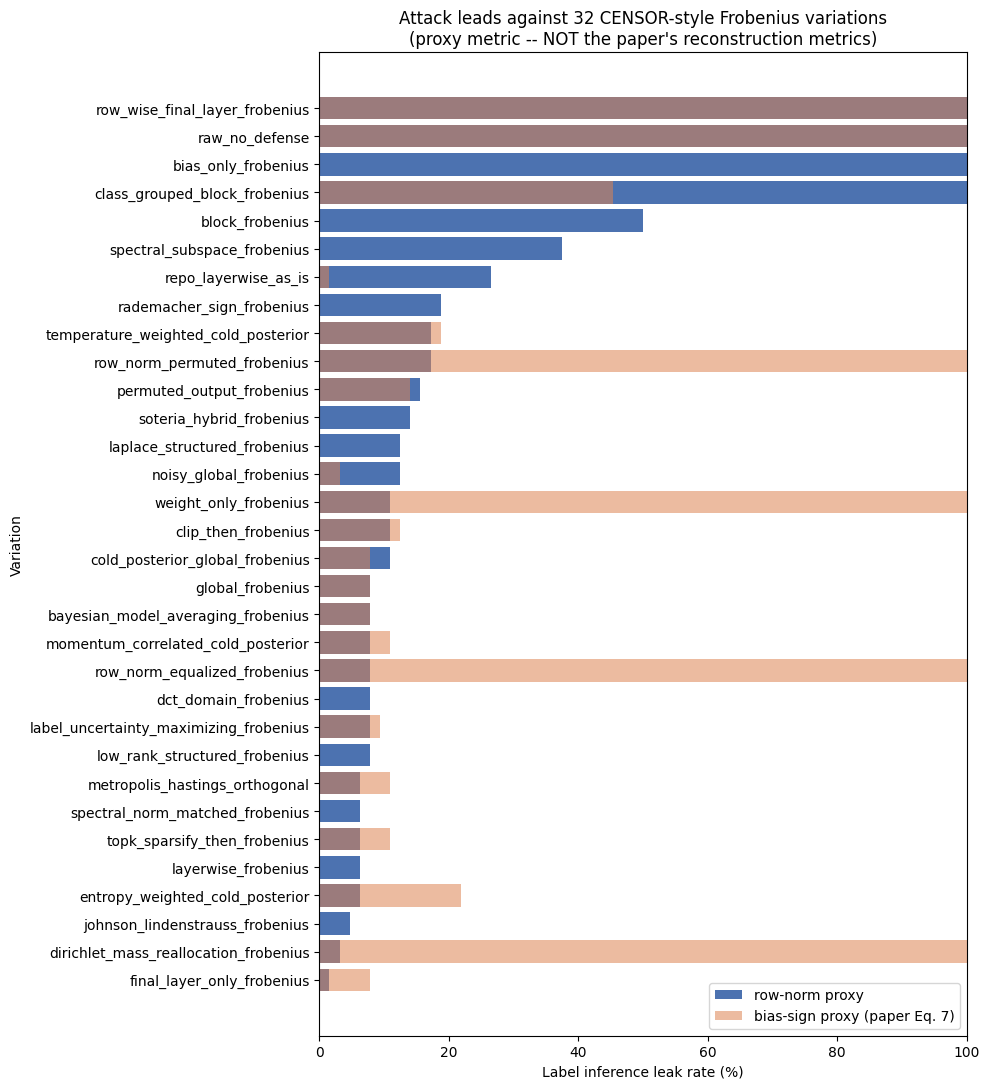

In [6]:
import matplotlib.pyplot as plt

plot_df = summary.sort_values('leak_rate_norm_pct')
plt.figure(figsize=(10, 11))
plt.barh(plot_df['name'], plot_df['leak_rate_norm_pct'], color='#4C72B0', label='row-norm proxy')
plt.barh(plot_df['name'], plot_df['leak_rate_sign_pct'], color='#DD8452', alpha=0.55, label='bias-sign proxy (paper Eq. 7)')
plt.xlabel('Label inference leak rate (%)')
plt.ylabel('Variation')
plt.title("Attack leads against 32 CENSOR-style Frobenius variations\n(proxy metric -- NOT the paper's reconstruction metrics)")
plt.legend(loc='lower right')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

## Ablations (same as the companion notebook)

- **Layer-wise vs. Entire gradient** -- mirrors the paper's Table VII.
- **Number of cold-posterior trials T** -- mirrors the paper's Figure 9.
- **`block_frobenius` alignment loophole** -- aligned vs. non-aligned block sizes.
- **Dirichlet mass-reallocation sweep** -- new, continuous interpolation between the row-norm-preserving and row-norm-equalizing negative/positive controls.


In [7]:
layer_rows = run_layerwise_vs_entire_ablation(args)
pd.DataFrame(layer_rows)

No pre-existing Kaggle CIFAR dataset found under /kaggle/input; falling back to torchvision download (requires internet access).


,config,leak_rate_norm_pct,leak_rate_sign_pct,avg_abs_cosine
0,Layer-wise gradient,3.1250,0.00,9.462313e-10
1,Entire gradient,7.8125,6.25,4.492299e-10


No pre-existing Kaggle CIFAR dataset found under /kaggle/input; falling back to torchvision download (requires internet access).


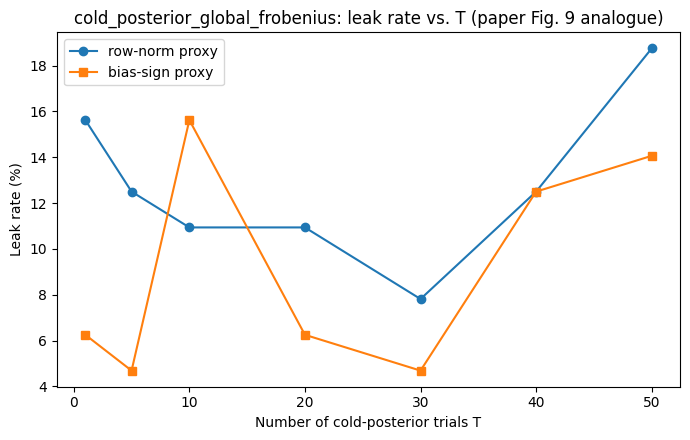

,trials,leak_rate_norm_pct,leak_rate_sign_pct,avg_selected_loss
0,1,15.6250,6.2500,1.554067
1,5,12.5000,4.6875,1.554067
2,10,10.9375,15.6250,1.554067
3,20,10.9375,6.2500,1.554067
4,30,7.8125,4.6875,1.554067
5,40,12.5000,12.5000,1.554067
6,50,18.7500,14.0625,1.554067


In [8]:
trials_rows = run_trials_ablation(args, trial_values=[1, 5, 10, 20, 30, 40, 50])
trials_df = pd.DataFrame(trials_rows)
plt.figure(figsize=(7, 4.5))
plt.plot(trials_df['trials'], trials_df['leak_rate_norm_pct'], marker='o', label='row-norm proxy')
plt.plot(trials_df['trials'], trials_df['leak_rate_sign_pct'], marker='s', label='bias-sign proxy')
plt.xlabel('Number of cold-posterior trials T'); plt.ylabel('Leak rate (%)')
plt.title("cold_posterior_global_frobenius: leak rate vs. T (paper Fig. 9 analogue)")
plt.legend(); plt.tight_layout(); plt.show()
trials_df

In [9]:
block_rows = run_block_alignment_ablation(args, block_sizes=[32, 64, 96, 128, 256, 300])
pd.DataFrame(block_rows)

No pre-existing Kaggle CIFAR dataset found under /kaggle/input; falling back to torchvision download (requires internet access).


,block_size,divides_fc_row_length,leak_rate_norm_pct,leak_rate_sign_pct
0,32,True,100.000,0.0000
1,64,True,100.000,0.0000
2,96,False,100.000,0.0000
3,128,True,100.000,0.0000
4,256,False,46.875,0.0000
5,300,False,50.000,4.6875


No pre-existing Kaggle CIFAR dataset found under /kaggle/input; falling back to torchvision download (requires internet access).


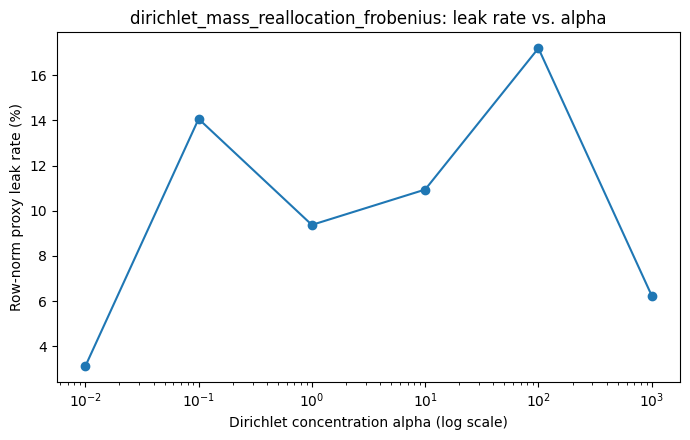

,alpha,leak_rate_norm_pct,leak_rate_sign_pct
0,0.01,3.1250,100.0
1,0.10,14.0625,100.0
2,1.00,9.3750,100.0
3,10.00,10.9375,100.0
4,100.00,17.1875,100.0
5,1000.00,6.2500,100.0


In [10]:
dirichlet_rows = run_dirichlet_alpha_ablation(args, alpha_values=[0.01, 0.1, 1.0, 10.0, 100.0, 1000.0])
dirichlet_df = pd.DataFrame(dirichlet_rows)
plt.figure(figsize=(7, 4.5))
plt.semilogx(dirichlet_df['alpha'], dirichlet_df['leak_rate_norm_pct'], marker='o')
plt.xlabel('Dirichlet concentration alpha (log scale)'); plt.ylabel('Row-norm proxy leak rate (%)')
plt.title('dirichlet_mass_reallocation_frobenius: leak rate vs. alpha')
plt.tight_layout(); plt.show()
dirichlet_df

## Heavier run

```python
args.dataset = 'CIFAR100'          # attach a CIFAR-100 Kaggle dataset as input too
args.train_batches = 1000
args.eval_samples = 200
args.trials = 50
rows, meta = run_experiment(args)
summarize(rows, meta)
```

See the accompanying PDF research report for the full mathematical
discussion of every variant above, why the negative-control variants show
100% "leak rate" on this proxy (and why that is not a break of CENSOR), and
a taxonomy of the four design axes the 21 new variants explore.
